In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score

In [2]:
df = pd.read_csv("online vs store shopping dataset.csv")

print(df.head())

   age  monthly_income  daily_internet_hours  smartphone_usage_years  \
0   56          221111                   6.5                      12   
1   69           96029                   8.2                      13   
2   46           19055                   6.4                       4   
3   32           53170                   6.4                      11   
4   60          244016                   6.0                       5   

   social_media_hours  online_payment_trust_score  tech_savvy_score  \
0                 0.7                           1                 6   
1                 2.7                           6                 9   
2                 2.1                          10                 8   
3                 0.7                           2                10   
4                 0.7                           2                 5   

   monthly_online_orders  monthly_store_visits  avg_online_spend  ...  \
0                     16                    16             28551  .

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11789 entries, 0 to 11788
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   age                          11789 non-null  int64  
 1   monthly_income               11789 non-null  int64  
 2   daily_internet_hours         11789 non-null  float64
 3   smartphone_usage_years       11789 non-null  int64  
 4   social_media_hours           11789 non-null  float64
 5   online_payment_trust_score   11789 non-null  int64  
 6   tech_savvy_score             11789 non-null  int64  
 7   monthly_online_orders        11789 non-null  int64  
 8   monthly_store_visits         11789 non-null  int64  
 9   avg_online_spend             11789 non-null  int64  
 10  avg_store_spend              11789 non-null  int64  
 11  discount_sensitivity         11789 non-null  int64  
 12  return_frequency             11789 non-null  int64  
 13  avg_delivery_day

In [4]:
df.describe()

,age,monthly_income,daily_internet_hours,smartphone_usage_years,social_media_hours,online_payment_trust_score,tech_savvy_score,monthly_online_orders,monthly_store_visits,avg_online_spend,...,return_frequency,avg_delivery_days,delivery_fee_sensitivity,free_return_importance,product_availability_online,impulse_buying_score,need_touch_feel_score,brand_loyalty_score,environmental_awareness,time_pressure_level
count,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,...,11789.00000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000,11789.000000
mean,48.729409,131704.282382,6.011367,7.597930,2.514471,5.498770,5.534312,24.677581,9.482144,74554.929341,...,4.46747,3.999661,5.468827,5.462041,5.518704,5.486386,5.485368,5.532021,5.448554,5.504114
std,17.899445,68120.726684,1.976811,4.011628,1.263047,2.880366,2.887251,14.431277,5.728825,43167.126595,...,2.88545,1.995881,2.870195,2.882177,2.867613,2.877918,2.877264,2.848796,2.872740,2.876561
min,18.000000,15005.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,523.000000,...,0.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,33.000000,72450.000000,4.600000,4.000000,1.600000,3.000000,3.000000,12.000000,5.000000,36797.000000,...,2.00000,2.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000
50%,49.000000,131916.000000,6.000000,8.000000,2.500000,5.000000,6.000000,25.000000,9.000000,74859.000000,...,4.00000,4.000000,5.000000,5.000000,6.000000,5.000000,5.000000,6.000000,5.000000,6.000000
75%,64.000000,190505.000000,7.400000,11.000000,3.400000,8.000000,8.000000,37.000000,14.000000,112134.000000,...,7.00000,6.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000
max,79.000000,249989.000000,12.000000,14.000000,6.000000,10.000000,10.000000,49.000000,19.000000,149996.000000,...,9.00000,7.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000


In [5]:
print(df.isnull().sum())

age                            0
monthly_income                 0
daily_internet_hours           0
smartphone_usage_years         0
social_media_hours             0
online_payment_trust_score     0
tech_savvy_score               0
monthly_online_orders          0
monthly_store_visits           0
avg_online_spend               0
avg_store_spend                0
discount_sensitivity           0
return_frequency               0
avg_delivery_days              0
delivery_fee_sensitivity       0
free_return_importance         0
product_availability_online    0
impulse_buying_score           0
need_touch_feel_score          0
brand_loyalty_score            0
environmental_awareness        0
time_pressure_level            0
gender                         0
city_tier                      0
shopping_preference            0
dtype: int64


In [6]:
df[df.duplicated(keep='first')]

,age,monthly_income,daily_internet_hours,smartphone_usage_years,social_media_hours,online_payment_trust_score,tech_savvy_score,monthly_online_orders,monthly_store_visits,avg_online_spend,...,free_return_importance,product_availability_online,impulse_buying_score,need_touch_feel_score,brand_loyalty_score,environmental_awareness,time_pressure_level,gender,city_tier,shopping_preference


In [7]:
df = df.drop(['environmental_awareness','city_tier','time_pressure_level', 'smartphone_usage_years', 'discount_sensitivity', 'return_frequency', 'avg_delivery_days', 'delivery_fee_sensitivity', 'free_return_importance', 'product_availability_online'], axis=1)

In [8]:
df.columns

Index(['age', 'monthly_income', 'daily_internet_hours', 'social_media_hours',
       'online_payment_trust_score', 'tech_savvy_score',
       'monthly_online_orders', 'monthly_store_visits', 'avg_online_spend',
       'avg_store_spend', 'impulse_buying_score', 'need_touch_feel_score',
       'brand_loyalty_score', 'gender', 'shopping_preference'],
      dtype='object')

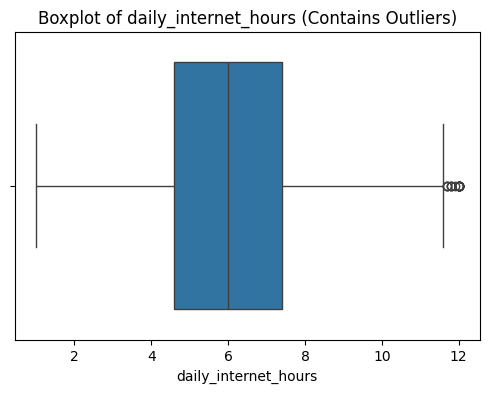

In [9]:
#Select Numeric Columns
numeric_df = df.select_dtypes(include=['int64','float64'])

#Detect Columns with Outliers
outlier_columns = []

for col in numeric_df.columns:
    Q1 = numeric_df[col].quantile(0.25)
    Q3 = numeric_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    if ((numeric_df[col] < lower) | (numeric_df[col] > upper)).any():
        outlier_columns.append(col)

#Plot Boxplots for Outliers
for col in outlier_columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col} (Contains Outliers)")
    plt.show()

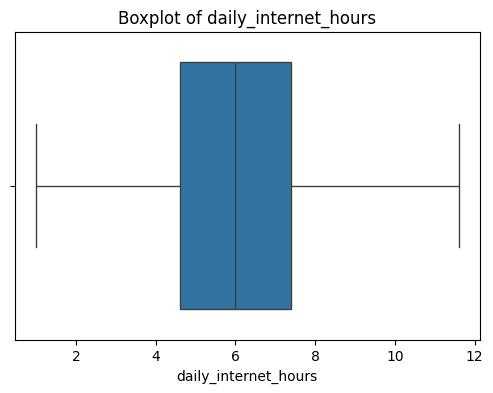

In [10]:
#Remove Outliers Using IQR
for col in numeric_df.columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

#Plot Boxplots for Outliers
for col in outlier_columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

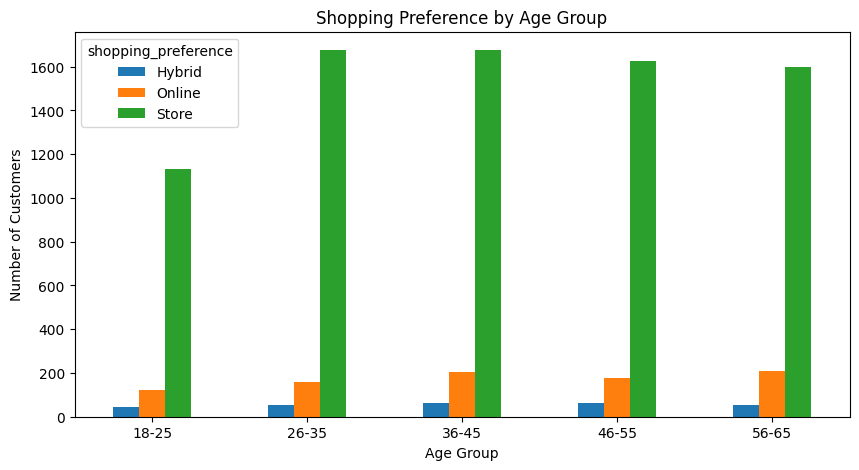

In [11]:
bins = [18,25,35,45,55,65]
labels = ['18-25','26-35','36-45','46-55','56-65']

df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)

preference_analysis = df.groupby(['age_group','shopping_preference'], observed=False).size().unstack()

preference_analysis.plot(kind='bar', figsize=(10,5))

plt.title("Shopping Preference by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")
plt.xticks(rotation=360)

plt.show()

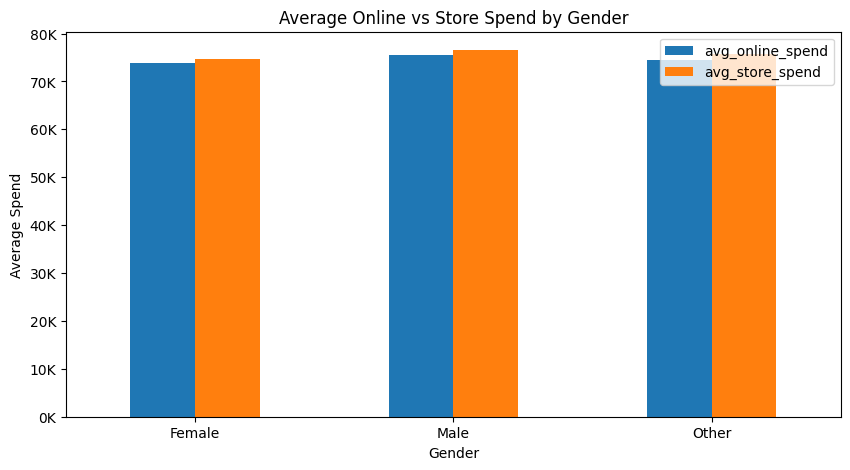

In [12]:
spending = df.groupby('gender')[['avg_online_spend','avg_store_spend']].mean()

def format_k(x, pos):
    return f'{int(x/1000)}K'

ax = spending.plot(kind='bar', figsize=(10,5))

ax.yaxis.set_major_formatter(FuncFormatter(format_k))

plt.title("Average Online vs Store Spend by Gender")
plt.ylabel("Average Spend")
plt.xlabel("Gender")
plt.xticks(rotation=360)

plt.show()

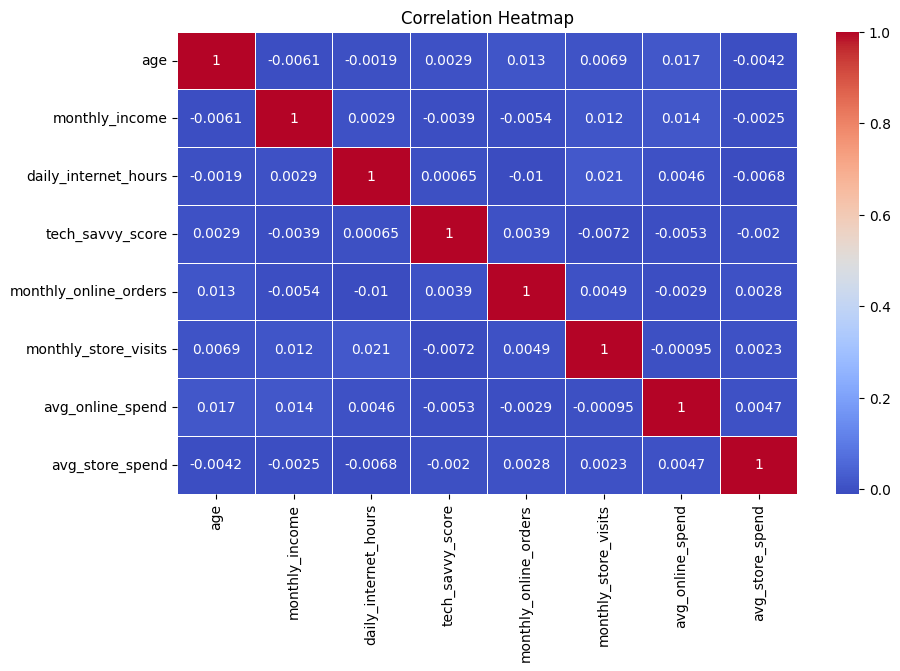

In [13]:
selected_columns = df[['age', 'monthly_income', 'daily_internet_hours', 'tech_savvy_score', 'monthly_online_orders', 'monthly_store_visits', 'avg_online_spend', 'avg_store_spend']]

correlation = selected_columns.corr()

plt.figure(figsize=(10,6))
sns.heatmap(correlation, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

In [14]:
df = df.drop(['age_group'], axis=1)

In [15]:
df['gender'] = df['gender'].map({'Male':0,'Female':1,'Other':2})
df['shopping_preference'] = df['shopping_preference'].map({'Store':0, 'Online':1, 'Hybrid':2})

In [16]:
X = df.drop('shopping_preference', axis=1)
y = df['shopping_preference']

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [18]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [19]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred_rf))

Accuracy: 0.9549511262218444


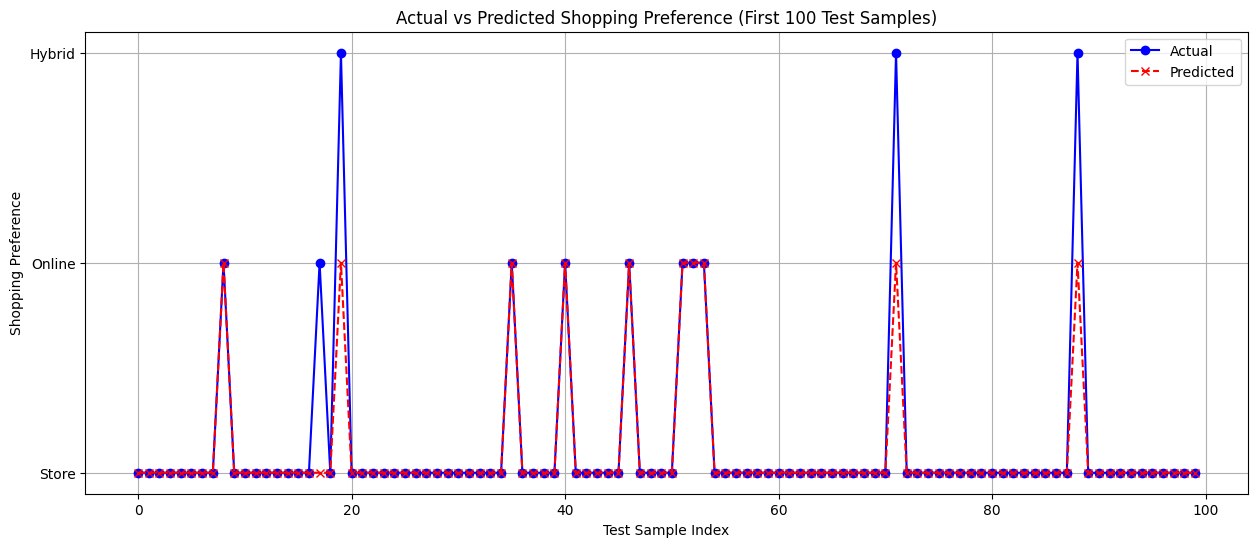

In [20]:
plt.figure(figsize=(15,6))

plt.plot(y_test.values[:100],
         label='Actual',
         color='blue',
         marker='o')

plt.plot(pred_rf[:100],
         label='Predicted',
         color='red',
         linestyle='--',
         marker='x')

plt.title("Actual vs Predicted Shopping Preference (First 100 Test Samples)")
plt.xlabel("Test Sample Index")
plt.ylabel("Shopping Preference")

plt.yticks([0, 1, 2], ['Store', 'Online', 'Hybrid'])

plt.legend()
plt.grid(True)

plt.show()